# Homework 1: Thinking About Data

BEE 4850/5850

**Name**: Madeline Allen

**ID**: mca76

> **Due Date**
>
> Friday, 2/7/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to introduce you to
simulation-based data analysis.

-   Problem 1 asks you to find an example of a spurious correlation.
-   Problem 2 asks you to explore whether a difference between data
    collected from two groups might be statistically meaningful or the
    result of noise. This problem repeats the analysis from [Statistics
    Without The Agonizing
    Pain](https://www.youtube.com/watch?v=5Dnw46eC-0o) by John Rauser
    (which is a neat watch!).
-   Problem 3 asks you to explore the impacts of selection biases on
    statistical relationships.
-   Problem 4 asks you to evaluate an interview method for finding the
    level of cheating on a test to determine whether cheating was
    relatively high or low. This problem was adapted from [Bayesian
    Methods for
    Hackers](https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/).
-   Problem 5 (only required for students in BEE 5850) asks you to
    propose several causal models for the same observational phenomenon.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [329]:
# import Pkg
# Pkg.activate(@__DIR__)
# Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [330]:
# using Random # random number generation and seed-setting
# using DataFrames # tabular data structure
# using CSVFiles # reads/writes .csv files
# using Distributions # interface to work with probability distributions
# using Plots # plotting library
# using StatsBase # statistical quantities like mean, median, etc
# using StatsPlots # some additional statistical plotting tools

The separate code bee5850_setup_env.py was used to create a python environment that has the equivalent python packages as the Julia ones listed above. The code below loads the packages.

In [331]:
# Packages:
import pandas as pd
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns 

## Problems

### Scoring

Each problem is worth 5 points.

### Problem 1

Find an example of a spurious correlation (don’t just pull from
[Spurious
Correlations!](https://www.tylervigen.com/spurious-correlations)!).

**In this problem**:

-   Describe and illustrate the correlation;
-   Explain why you think the correlation is spurious.

In [ ]:
# Load data into a DataFrame, isolate years of data that both datasets have (2006 to 2021)
happy_og = pd.read_csv("data/World Happiness Report.csv")
happy =happy_og[happy_og['Year']<2022] 
meat_og = pd.read_csv("data/Consumption of meat per capita.csv")
meat = meat_og[meat_og['Year']>2005]

# Isolate US
meat_US = meat[meat['Entity']=='United States']
happy_US = happy[happy['Country Name']== 'United States']

# Merge for easier analysis
merged_df = pd.merge(meat_US, happy_US, left_on='Year', right_on = 'Year', how='left')
merged_df_ref = merged_df[['Poultry', 'Beef', 'Sheep and goat', 'Pork',
       'Other meats', 'Fish and seafood', 'Life Ladder', 'Log GDP Per Capita', 'Social Support',
       'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices',
       'Generosity', 'Perceptions Of Corruption', 'Positive Affect',
       'Negative Affect', 'Confidence In National Government']]

# print(merged_df_ref.head(10))

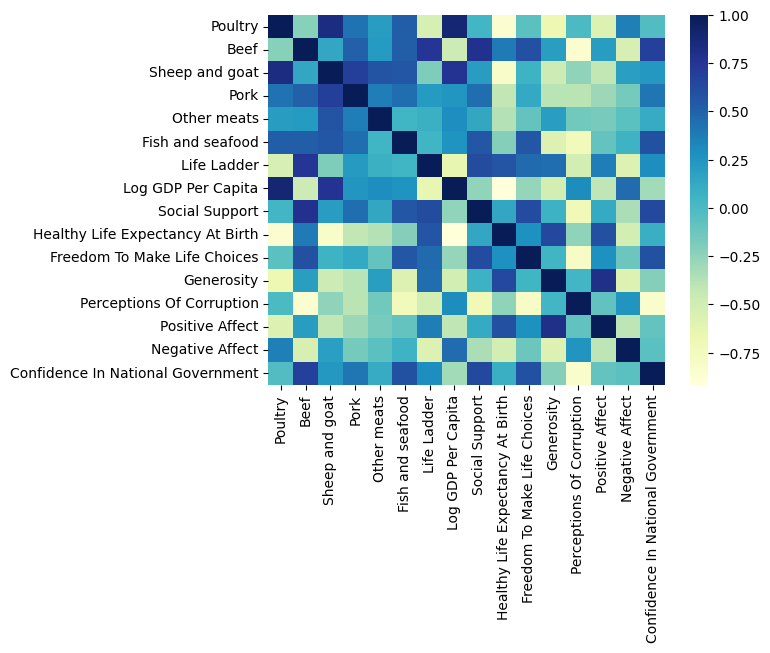

In [327]:
# examine correlations
correlation_matrix = merged_df_ref.corr() 
dataplot = sns.heatmap(merged_df_ref.corr(numeric_only=True), cmap="YlGnBu", annot=False)

In [328]:
print('Correlation between beef and freedom:',merged_df['Beef'].corr(merged_df['Freedom To Make Life Choices']))
print('Correlation between beef and corruption:',merged_df['Beef'].corr(merged_df['Perceptions Of Corruption']))

Correlation between beef and freedom: 0.596103085901939
Correlation between beef and corruption: -0.8599874718104089


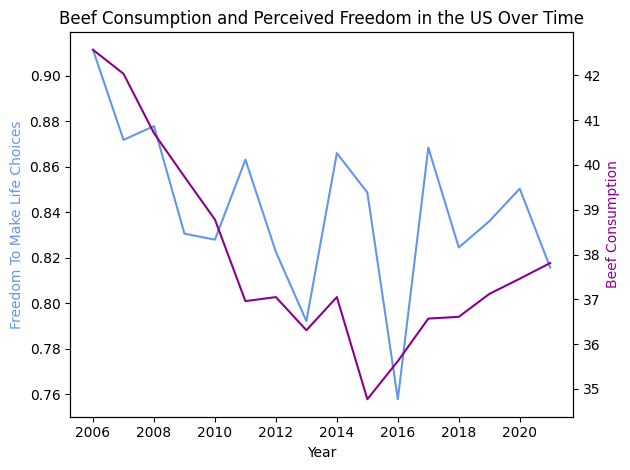

In [318]:
# Create the figure and the first axis
fig, ax1 = plt.subplots()

# first axis
ax1.plot(merged_df['Year'], merged_df['Freedom To Make Life Choices'], color='cornflowerblue')
ax1.set_ylabel('Freedom To Make Life Choices', color='cornflowerblue')
ax1.set_xlabel('Year')
ax1.set_title('Beef Consumption and Perceived Freedom in the US Over Time')

# second axis
ax2 = ax1.twinx()
ax2.plot(merged_df['Year'], merged_df['Beef'], color='darkmagenta')
ax2.set_ylabel('Beef Consumption', color='darkmagenta')


# Show the plot
plt.tight_layout()
plt.show()

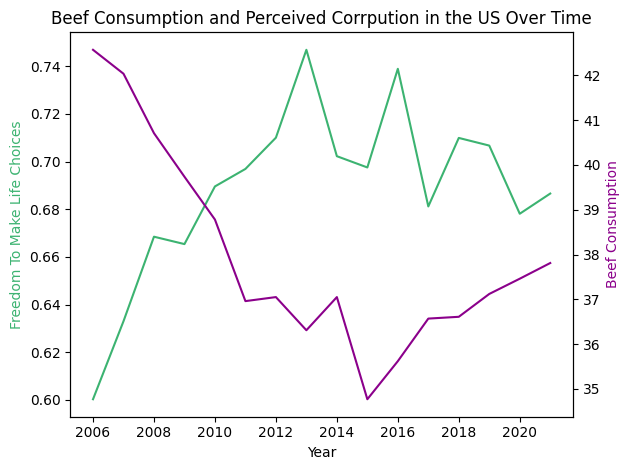

In [324]:
# Create the figure and the first axis
fig, ax1 = plt.subplots()

# first axis
ax1.plot(merged_df['Year'], merged_df['Perceptions Of Corruption'], color='mediumseagreen')
ax1.set_ylabel('Freedom To Make Life Choices', color='mediumseagreen')
ax1.set_xlabel('Year')
ax1.set_title('Beef Consumption and Perceived Corrpution in the US Over Time')

# second axis
ax2 = ax1.twinx()
ax2.plot(merged_df['Year'], merged_df['Beef'], color='darkmagenta')
ax2.set_ylabel('Beef Consumption', color='darkmagenta')

# Show the plot
plt.tight_layout()
plt.show()

**ANSWER**: Disclaimer - I know this is such a weird and random example, I downloaded a bunch of different datasets to look for different correlations that I had reasons to believe they would be there e.g., ice cream production and heat stroke - both connected by hot temps; ice cream production and acres of wildfire in california - also connected by hot temps; GDP and a measure of happiness - but then I realized GDP was part of the happiness calcultion; etc. - most of them didn't pan out the way I thought they would and/or the data I was able to obtain for them was sufficiently difficult to clean and align that I ended up abandoning the idea.

So! Here are two funny (in my opinion) examples I found. 

**Describe and illustrate the correlatiom:**
The two datasets I looked at were the World Happiness Report published by the Sustainable Development Solutions Network (Buttar, 2022), and Meat consumption per capita by the Food and Agriculture Organization of the United Nations (Scibearia, 2024) (see full citations at end of homework). Above, I examined just the US data from the years the two datasets overlap (2006 to 2021).

For more information, see dataset documentation, but briefly quoted from the metadata - the freedom to make life choices variable was "the national average of binary responses to the GWP question “Are you satisfied or dissatisfied with your freedom to choose what you do with your life?”" (Buttar, 2022); and perception of corruption is "the average of binary answers to two GWP questions: “Is corruption widespread throughout the government or not?” and “Is corruption widespread within businesses or not?”" (Buttar, 2022). I also want to note that I did not look into the quality of either of these datasets closely.

The heat map of the correlations in the merged dataset above highlight some of the correlations between the per capita meat consumption of different meats in the US, and various metrics of happiness in the World Happiness Report dataset. The two spurious correlations I am highlighting are **1) the correlation between beef and (perceived) freedom to make life chocies was 0.60** which is a moderately strong correlation (i.e., as beef consumption decreases, freedom to make life choices also decreases) and **2) the correlation between beef and perceived corruption was -0.86,** which is a strong negative correlation (i.e., as beef consumption goes down, perceived corruption goes up). These correlations are also highlighted in line plots showing the trends of the variables over time (and illustrating the moderate positive and strongly negative correlations, respectively).

**Explain why you think the correlation is spurious:**
I think that it would be a difficult stretch for someone to genuinely believe that there is a casual link between these things, but with the state of the country right now I wouldn't be shocked to hear someone claiming that reduced beef consumption (e.g., through rising prices or reduced availability) is akin to a loss of freedom, and I also can imagine someone making a claim that corruption in government/business was negatively impacting the beef industry in such a way that beef consumption is going down (while corruption is going up). I believe these correlations are spurious, there are a wide variety of confounding variables that could result in the correlations we see - I think that in general, the reduction in beef consumption is likely a combination of 1) growing awareness of the negative health impacts of eating red meat; 2) increasing cost of beef (espeically high quality beef); 3) large increase in vegan or vegetarian meat substitutes; 4) growing awareness of the impacts of cattle industry on climate; and many other factors. I think the general trends in perceived freedom and corruption are probably influenced by the social, political, and economic landscape of the US (countless factors). 

One example of a potential confounding variable is tied to economics - as the cost of living in many places has risen over the past couple decades, it's possible that this has led to both a decrease in the consumption of beef (too expensive to eat as frequently as in e.g., 2006), and that the rising cost of living is causing people to feel more constrained in their day-to-day life choices and autonomy (resulting in a lowering of perceived freedom to make life choices). 

Honestly, I thought of way more straightforward spurious relationships (some of which mentioned in the first paragraph) but this is the one I ended up finding data that didn't require extensive cleaning prior to analysis.

### Problem 2

The underlying question we would like to address is: what is the
influence of drinking beer on the likelihood of being bitten by
mosquitoes? There is a mechanistic reason why this might occur:
mosquitoes are attracted by changes in body temperature and released
CO<sub>2</sub>, and it might be that drinking beer induces these
changes. We’ll analyze this question using (synthetic) data which
separates an experimental population into two groups, one which drank
beer and the other which drank only water.

First, we’ll load data for the number of bites reported by the
participants who drank beer. This is in a comma-delimited file,
`data/bites.csv` (which is grossly overkill for this assignment). Each
row contains two columns: the group (`beer` and `water`) the person
belonged to and the number of times that person was bitten.

In Julia, we can do this using
[`CSVFiles.jl`](https://github.com/queryverse/CSVFiles.jl), which will
read in the `.csv` file into a
[`DataFrame`](https://dataframes.juliadata.org/stable/), which is a
typical data structure for tabular data (and equivalent to a Pandas
`DataFrame` in Python or a `dataframe` in R).

In [57]:
# data = DataFrame(load("data/bites.csv")) # load data into DataFrame

# # print data variable (semi-colon suppresses echoed output in Julia, which in this case would duplicate the output)
# @show data;

# Load data into a DataFrame
data = pd.read_csv("data/bites.csv")

# Print data
print(data.head(10))

  group  bites
0  beer     27
1  beer     20
2  beer     21
3  beer     26
4  beer     27
5  beer     31
6  beer     24
7  beer     21
8  beer     20
9  beer     19


How can we tell if there’s a meaningful difference between the two
groups? Naively, we might just look at the differences in group means.

> **Broadcasting**
>
> The subsetting operations in the below code use `.==`, which
> “broadcasts” the element-wise comparison operator == across every
> element. The decimal in front of `==` indicates that this should be
> used element-wise (every pair of elements compared for equality,
> returning a vector of `true` or `false` values); otherwise Julia would
> try to just check for vector equality (returning a single `true` or
> `false` value).
>
> Broadcasting is a very specific feature of Julia, so this syntax would
> look different in a different programming language.

In [ ]:
# # split data into vectors of bites for each group
# beer = data[data.group .== "beer", :bites]
# water = data[data.group .== "water", :bites]

# observed_difference = mean(beer) - mean(water)
# @show observed_difference;

#Chatgpt (OpenAI, 2024) was used to convert the Julia code above into the python code below. I copied and pasted the code above into Chatgpt and asked it to translate from julia to python.

# Split data into vectors of bites for each group
beer = data.loc[data["group"] == "beer", "bites"]
water = data.loc[data["group"] == "water", "bites"]

# Compute the observed difference in means
observed_difference_og = beer.mean() - water.mean()

# Print the observed difference
print("observed_difference:", observed_difference_og)


observed_difference: 4.37777777777778


This tells us that, on average, the participants in the experiment who
drank beer were bitten approximately 4.4 more times than the
participants who drank water! Does that seem like a meaningful
difference, or could it be the result of random chance?

We will use a *simulation* approach to address this question, as
follows.

-   Suppose someone is skeptical of the idea that drinking beer could
    result in a higher attraction to mosquitoes, and therefore more
    bites. To this skeptic, the two datasets are really just different
    samples from the same underlying population of people getting bitten
    by mosquitoes, rather than two different populations with different
    propensities for being bitten. This is the skeptic’s *hypothesis*,
    versus our hypothesis that drinking beer changes body temperature
    and CO<sub>2</sub> release sufficiently to attract mosquitoes.
-   If the skeptic’s hypothesis is true, then we can “shuffle” all of
    the measurements between the two datasets and re-compute the
    differences in the means. After repeating this procedure a large
    number of times, we would obtain a distribution of the differences
    in means under the assumption that the skeptic’s hypothesis is true.
-   Comparing our experimentally-observed difference to this
    distribution, we can then evaluate the consistency of the skeptic’s
    hypothesis with the experimental results.

> **Why Do We Call This A Simulation-Based Approach?**
>
> This is a simulation-based approach because the “shuffling” is a
> non-parametric way of generating new samples from the underlying
> distribution (more on this later!).
>
> The alternative to this approach is to use a statistical test, such as
> a [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), which
> [may have other
> assumptions](https://en.wikipedia.org/wiki/Student%27s_t-test#Assumptions)
> which may not be appropriate for this setting, particularly given the
> seemingly small sample sizes.

**In this problem**:

-   Conduct the above procedure to generate 50,000 simulated datasets
    under the skeptic’s hypothesis.
-   Plot a histogram of the results and add a dashed vertical line to
    show the experimental difference (if you are using Julia, feel free
    to look at the [Making Plots with Julia
    tutorial](https://viveks.me/simulation-data-analysis/tutorials/julia-plots.html)
    on the class website).
-   Draw conclusions about the plausibility of the skeptic’s hypothesis
    that there is no difference between groups. Feel free to use any
    quantitative or qualitative assessments of your simulations and the
    observed difference.

In [219]:
# For each of the 50,000 simulations, shuffle the bites column, recompute the difference between groups,
# store that info, and repeat.

#Note - I used chatgpt to figure out the one line of code that shuffles the dataset below; I told chatgpt I had a dataframe 
# and wanted to shuffle one column in python without shuffling the other columns, 
# and it provided the suggestion that i use np.random.permutation()

np.random.seed(4)

m = 50000
obs_dif_list = []

for sim in np.arange(1,m+1):
    # Shuffle only the 'bites' column
    data["bites"] = np.random.permutation(data["bites"])

    # Split data into groups; compute obs difference in means
    beer = data.loc[data["group"] == "beer", "bites"]
    water = data.loc[data["group"] == "water", "bites"]

    diff = beer.mean() - water.mean()
    obs_dif_list.append(diff)


# print(obs_dif_list)

In [223]:
# Count the number of simulated values 
sim_greater_obs = [i for i in obs_dif_list if i >= observed_difference_og]
print('Number of simulated results greater than original observed experimental difference: ', len(sim_greater_obs))

print('Fraction of simulated results greater than original observed experimental difference: ', len(sim_greater_obs)/len(obs_dif_list))


Number of simulated results greater than original observed experimental difference:  25
Fraction of simulated results greater than original observed experimental difference:  0.0005


In [225]:
# Count the number of simulated values 
sim_greater_obs = [i for i in obs_dif_list if np.abs(i) >= np.abs(observed_difference_og)]
print('Number of simulated results more extreme than original observed experimental difference: ', len(sim_greater_obs))

print('Fraction of simulated results more extreme than original observed experimental difference: ', len(sim_greater_obs)/len(obs_dif_list))


Number of simulated results more extreme than original observed experimental difference:  51
Fraction of simulated results more extreme than original observed experimental difference:  0.00102


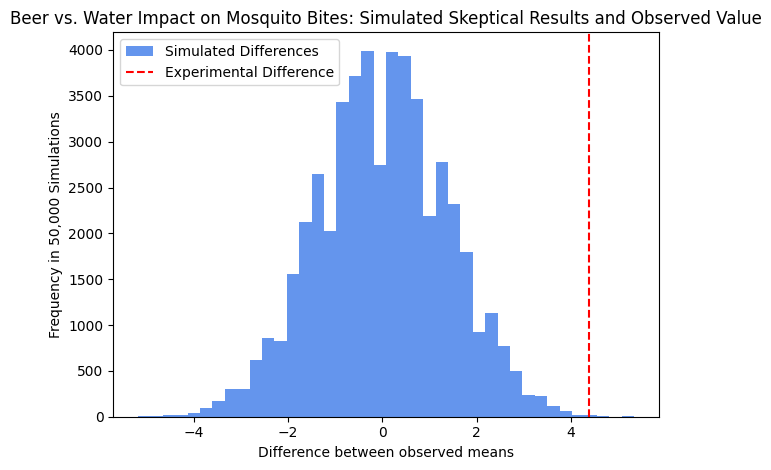

In [221]:
# histogram of possible differences via simulation, and show where o.g., one falls:
plt.hist(obs_dif_list, color = 'cornflowerblue', bins = 40, label='Simulated Differences')
# add vertical line for og observed difference:
plt.axvline(x=observed_difference_og, color='red', linestyle='--', label = 'Experimental Difference')
plt.xlabel('Difference between observed means')
plt.ylabel('Frequency in 50,000 Simulations')
plt.title('Beer vs. Water Impact on Mosquito Bites: Simulated Skeptical Results and Observed Value')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

**ANSWER:** The histogram above shows the results from 50,000 simulated datasets, where the original dataset was shuffled (specifically, the bites column was shuffled), and the difference in the number of bites on average for the beer group and the water group were computed. The red dashed line shows the origianl observed experimental value. If the skeptic's hypothesis was true (i.e., the beer and water groups are just samples from the same underlying population, instead of two different populations that are being bitten at different rates), we would expect the original observed experimental value to appear "likely" or "probable" compared to the 50,000 simulations where the beer vs water distinction was not preserved. 

Instead, we see that the original observed experimental value is located in the tail of the simulated histogram, **suggesting that the skeptic's hypothesis** that the datasets from the two groups (beer and water) are really coming from the same underlying population, is **not very plausible**. To add a slightly more quantitative interpretation of the results shown above - only 25 of the 50,000 simulated results had results larger (with sign considered) than the original experimental observed difference (i.e., roughly 0.05% of the simulated results). If we disregard sign (i.e., look for how many simulated results were more extreme than the observed difference), these numbers are roughly double (51 simulated results are more extreme, which is roughly .102%) - which is still very small. I'm not sure of the correct wording to describe quantitatively how unlikely this observed experimental result is (beyond what I've written above), but both quantitative and qualitative analyses of these results lead me to conclude that the skeptic's hyptohesis is not very plausible. Note that this does not necessarily make the alternative hypothesis true (that beer vs water is the difference that is causing one population to be bitten more than the other), but it is unlikely the datasets from these two groups are coming from the same underlying population (i.e., there is likely something that is causing the beer group folks to have a higher propensity for being bitten).

### Problem 3

A scientific funding agency receives 200 proposals in response to a
call. The panel is asked to evaluate each proposal on two criteria:
scientific rigor and potential impact (or “newsworthiness”). After
standardizing each of these scores to independently follow a standard
normal distribution ($\text{Normal}(0, 1)$), the two standardized scores
are summed to get the total score for the proposal. Based on these total
scores, the top 10% of the proposals are selected for funding.

A researcher who is studying the relationship between rigor and impact
has used data on the funded proposals to claim high-impact proposals are
necessarily less rigorous, and indeed found a statistically significant
negative correlation between the rigor and impact scores for the funded
proposals. You are more skeptical and believe this effect is an artifact
from the selection process, which would make the claim a bit ironic.

**In this problem**:

-   Create a generative model for the grant-selection procedure under
    the null assumption of no correlation between rigor and impact. You
    can sample rigor and impact scores directly from
    $\text{Normal}(0, 1)$.
-   Using 1,000 simulations, compare the distribution of correlations
    between rigor and impact for the funded proposals to the general
    proposal population.
-   Explain why, when conditioning on selection for funding, there might
    be a negative correlation between rigor and impact even when none
    generally exists.

> **Selection-Distortion Effects**
>
> These **selection-distortion effects** are pretty common in
> observational data, going back to [work by Dawes in the 1970s on the
> lack of predictive ability of admission variables on student
> success](https://www.science.org/doi/abs/10.1126/science.187.4178.721)
> and including [studies claiming to identify a causal fingerprint of
> genes on
> outcomes](https://www.nature.com/articles/s41598-021-89020-x).
>
> This is, of course, just one example of how not thinking carefully
> about data-generating processes can fundamentally contaminate
> statistical analyses, emphasizing that **data do not have meaning
> absent a model for how they were generated**.

In [239]:
# Create generative model (null assumption: no correlation between rigor and impact)
# simluations: 1,000; fore each simulation: n = 200 rigor and impact scores, sum to get total score, pick top 10%
m = 1000
n = 200

corr_selected = []
corr_all = []

mu = 0
sigma = 1

for sim in np.arange(1,m+1):
    sample = pd.DataFrame()
    # sample rigor from N(0,1); n = 200
    sample['rigor'] = np.random.normal(mu, sigma, 200)
    #print(rigor)

    # sample impact from N(0,1); n = 200
    sample['impact'] = np.random.normal(mu, sigma, 200)
    #print(impact)

    # add rigor to impact to get 'score'
    sample['score'] = sample['rigor']+sample['impact']
    #print(score)
    #print(sample)

    # sort by 'score' column (descending so that the largest are at the top of the df)
    # NOTE - I used chatgpt to figure out the following one line of code; at first I didn't have the inplace=True and I saw that my 
    # df wasn't being sorted properly, so i asked Chatgpt how to modify that line of code to make it sort properly, and it suggested
    # to add the inplace=True to modify the original df (which is what I was trying to do)
    sample.sort_values(by='score', ascending=False, inplace=True)
    # print('head',sample.head(10))
    # # print('tail',sample.tail(10))

    #isolate top 10% of applicants based on score
    n_selected = int(0.1*n) #i.e., 20 if n = 200
    selected_applicants = sample[:n_selected]
    #calculate correlation between rigor and impact for top 10%
    sample_corr_selected = selected_applicants['impact'].corr(selected_applicants['rigor'])
    corr_selected.append(sample_corr_selected)

    #calculate correlation between rigor and impact for all:
    sample_corr_all = sample['impact'].corr(sample['rigor'])
    corr_all.append(sample_corr_all)

# print('corr_all', corr_all)
# print('corr_selected', corr_selected)

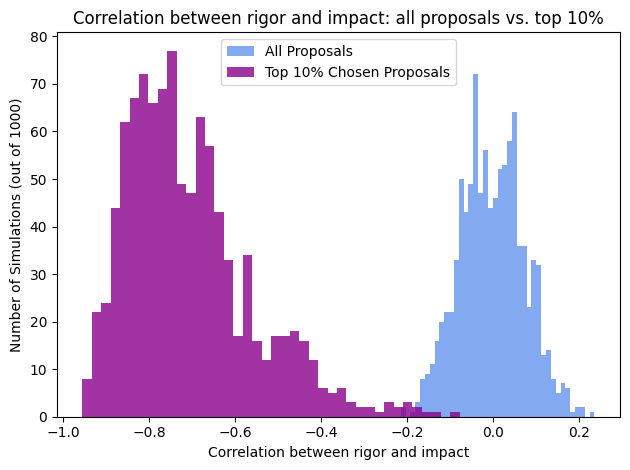

In [240]:
#Compare distribution of correlations between rigor and impact for funded proposals to the general proposal population:
# histogram of possible differences via simulation, and show where o.g., one falls:
plt.hist(corr_all, color = 'cornflowerblue', bins = 40, label='All Proposals', alpha = 0.8)
plt.hist(corr_selected, color = 'darkmagenta', bins = 40, label='Top 10% Chosen Proposals' , alpha = 0.8)
plt.xlabel('Correlation between rigor and impact')
plt.ylabel('Number of Simulations (out of 1000)')
plt.title('Correlation between rigor and impact: all proposals vs. top 10%')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [241]:
# test = np.random.normal(mu, 1, 1000)
# test2 = np.random.normal(mu, 1, 1000)
# test3 = test+test2
# test4 = np.random.normal(mu, 2, 1000)
# plt.hist(test, alpha = 0.8)
# plt.hist(test2, alpha = 0.8)
# plt.hist(test3, alpha = 0.8)
# plt.hist(test4, alpha = 0.8)

**ANSWER:** Examining the histograms above, we see that for the whole population of proposal submissions, the correlation between rigor and impact is centered on zero, and the majority of simulated results are between 0.2 and -0.2. This is because all rigor and impact values were drawn from a standard normal distribution independently, and on average, would have zero correlation with each other. However, we see that the histogram resulting from the chosen top 10% of proposals for each of the 1000 simulations results in largely negative correlation values. We see a negative correlation between rigor and impact when we condition on selection for funding because the top selected applicants were those whose summed rigor and impact scores were highest, and since rigor and impact are both on average zero, then it is very likely that when one - by chance - is large (e.g., a large rigor score), that the other value is not large (i.e., closer to zero). To confirm this thought, I examined the rigor and impact scores from some of the selected proposals (not shown, commented out that portion of code for clarity) - and saw that indeed sometimes you'll have both rigor and impact as large positive values, but much more frequently, you have a selected proposal with one large value (either rigor or impact), and one very small or even slightly negative value. E.g., a rigor of 2.8, and an impact of -0.46, resulting in a total score of 2.3.  With many of these occurences, we get a resulting negative correlation between rigor and impact for those selected applicants. This, as stated in the question framing, reminds us of the importance of why it is critical to consider the data-generating processes when conducting a statistical analysis.

### Problem 4

You are trying to detect how prevalent cheating was on an exam. You are
skeptical of the efficacy of just asking the students if they cheated.
You are also concerned about privacy — your goal is not to punish
individual students, but to see if there are systemic problems that need
to be addressed. Someone proposes the following interview procedure,
which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

We have a hypothesis that cheating was not prevalent, and the proportion
of cheaters was no more than 5% of the class; in other words, we expect
5 “true” cheaters out of a class of 100 students. Our TA is more jaded
and thinks that cheating was more rampant, and that 30% of the class
cheated. The proposed interview procedure is noisy: the interviewer does
not know if an admission means that the student cheated, or the result
of a heads. However, it gives us a data-generating process that we can
model and analyze for consistency with our hypothesis and that of the
TA.

**In this problem**:

-   Derive and code a simulation model for the above interview procedure
    given the “true” probability of cheating $p$.
-   Simulate your model (for a class of 100 students) 50,000 times under
    a null hypothesis of no cheating, your hypothesis of 5% cheating,
    the TA’s hypothesis of 30% cheating, and plot the resulting
    datasets.
-   If you received 31 “Yes, I cheated” responses while interviewing
    your class, what could you conclude?
-   How useful do you think the interview procedure is to identify
    systemic cheating? What changes to the design might you make?

In [246]:
# simulations m
m = 50000 
# class size
n = 100

#probabilities used in this simulation:
p_fair = 0.5
p_no_cheat = 0
p_cheat_notprev = 0.05
p_cheat_prev = 0.3
p_cheat_list = [0, 0.05, 0.3]
p_cheat_columns = ['no_cheat', 'cheat_notprev', 'cheat_prev']

# Dataframe to hold results
sim_report_cheat = pd.DataFrame(columns=p_cheat_columns)

# For each simulation:
for i in np.arange(0,3):

    #define probability of cheating
    p_cheat = p_cheat_list[i]

    #then do 50,000 simulations with that prob of cheating:
    sim_report_cheat_list = []
    for sim in np.arange(1,m+1):
        
        # Flip a fair coin first (probability p = 0.5); output is the number out of 100 that got 1 (need to answer honestly); n trials
        num_answer_honest = np.random.binomial(n, p_fair, 1)
        #print(num_answer_honest)

        # if the first flip is heads (1), then answer honestly (with probability of cheating p_cheat)
        honest_cheat = np.random.binomial(num_answer_honest, p_cheat, 1)
        #print(honest_cheat) 

        #if the first flip is tails (0), then flip again to get cheat or not cheat (fair coin; prob 0.5)
        coin_cheat = np.random.binomial((n-num_answer_honest), p_fair, 1)
        #print(coin_cheat)

        total_report_cheat = honest_cheat+coin_cheat
        #print(total_report_cheat)
        sim_report_cheat_list.append(total_report_cheat[0])
    sim_report_cheat[p_cheat_columns[i]] = sim_report_cheat_list

# sim_report_cheat


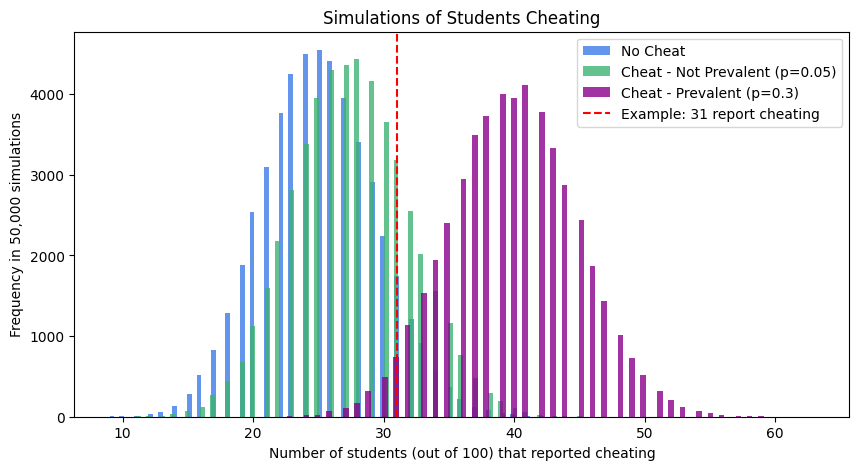

In [248]:
# Create the histogram
plt.figure(figsize=(10,5)) 

num_bins = 100

#Histograms of results
plt.hist(sim_report_cheat['no_cheat'], bins = num_bins, color='cornflowerblue', label='No Cheat')#, alpha = 0.8)
plt.hist(sim_report_cheat['cheat_notprev'], bins = num_bins, color='mediumseagreen', label='Cheat - Not Prevalent (p=0.05)', alpha = 0.8)
plt.hist(sim_report_cheat['cheat_prev'], bins = num_bins, color='darkmagenta', label='Cheat - Prevalent (p=0.3)', alpha = 0.8)

# add vertical line for example of 31:
plt.axvline(x=31, color='red', linestyle='--', label = 'Example: 31 report cheating')

# Add labels and legend
plt.xlabel('Number of students (out of 100) that reported cheating')
plt.ylabel('Frequency in 50,000 simulations')
plt.title('Simulations of Students Cheating')
plt.legend()

# Show the plot
plt.show()

**ANSWER:** The plot above shows three histograms of the results from 50,000 simulations of the experiment described above, with the probability of cheating being either p = 0.00, p = 0.05, or p = 0.30. From these results we see - as expected - that the histogram shifts towards the right (higher number of students reporting cheating) as the probability of cheating increases. If I conducted the experiment and had 31 students report cheating during an interview, **I would not feel confident drawing a strong conclusion on what is the correct probability of cheating, but I would say that out of the three options, the prevalent cheating (p=0.30) is the least likely, followed by no cheating, and thus a small amount of cheating (p=0.05) would be most likely - out of the three options.** Notably though, the least likely option - high level of cheating (p=0.3), still results in almost 1,000 of the 50,000 simulations resulting in 31 students reporting cheating, which in my opinion is too high of a number to confidently exclude the probability of a high level of cheating.

**Since I can't confidently tell the difference between these three cheating levels (p = 0, 0.05, and 0.3) based on this experimental design, I would say that this interview procedure is not very helpful for indentifying systematic cheating.** A key reason why it is nor particularly helpful is that the sampling variability is still very large (i.e., the histograms are still very wide and have a lot of overlap with one another). To make this interview procedure more helpful, I would need to reduce the variability. The only way I can think of to do this is increase my sample size. Since I can't simply manifest more students (i.e., number of students must reamil 100), then I could increase the number of times each student has to go through the interview procedure. I think that having students answer 5 or 10 times would essentially increase my sample size to 500 or 1000 respectively (although I think I would need to somehow account for the fact that the same student is answering several times - I'm not sure how to do that). If I could increase my sample size to 1000 in this way, then this would dramatically shrink the variability observed in the histograms, and they would have less overlap with one another (I tested this out by increasing n to 1000 above; not shown).

### Problem 5

**This problem is only required for students in BEE 5850**.

Adjusting for inflation, there has been an increase in tropical cyclone
damages on the U.S. Atlantic coast between 1900 and 2022 (see
<a href="#fig-tc" class="quarto-xref">Figure 1</a>).

<figure id="fig-tc">
<img src="attachment:figures/normalized-TC-damages.jpg" />
<figcaption>Figure 1: Change in tropical cyclone damages in U.S.
Atlantic coastal counties from 1900–2022, aggregated by pentad and
normalized to 2018 U.S. dollars. The red line shows an exponential trend
of 1.06%/yr growth in damages. Reproduced from <a
href="https://doi.org/10.1175/JAMC-D-24-0047.1">Willoughby, Hernandez,
&amp; Pinnock (2024)</a>.</figcaption>
</figure>

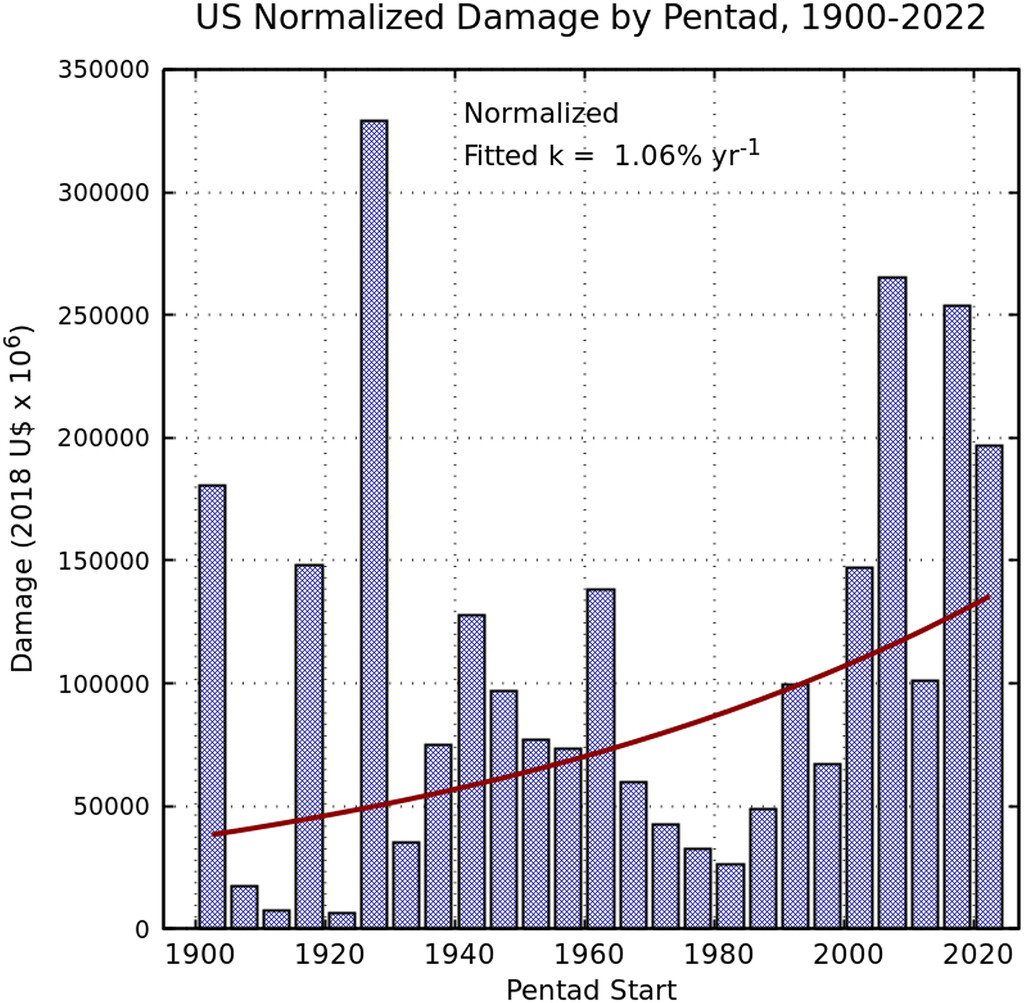

In [249]:
# I used chatgpt to display this figure becauase the markdown code above didn't work. 
# (I just copied and pasted markdown code in chatgpt and asked how to visualize usying jupyter notebook and python)
from IPython.display import display, Image

# Display the image from the figures folder
display(Image(filename="figures/normalized-TC-damages.jpg"))


**In this problem**:

-   Describe two different mechanisms by which tropical cyclone damages
    in coastal counties might have increased over this period.
-   How might you propose to examine the relative strengths of these
    mechanisms? You don’t need to actually do this (this is indeed a
    somewhat thorny debate in the literature), but think about potential
    modeling and data approaches.

Two mechanisms by which tropical cyclone damages in coastal counties might have increased over this period:

1) More frequent and/or more severe tropical cyclones hitting the US Atlantic coast over the time period 1900 and 2022. This could in part be due to increases in sea surface temperatures in the Atlantic or sea level rise (or several other physical changes to the system) - but to keep it simple for this question, I would say you could just examine the frequency and intensity of TCs over this time period to see if there has been a change (and then you could try to examine the physical causal mechanism later - as hundreds of scientists are doing right now).

2) Another mechanism is increased development along the coast - more people and property in areas that are in areas that are commonly hit by tropical cyclones would result in an increase of damages over time as development continues, regardless of whether the frequency/intensity of the TC changes.

Dividing the mechanisms in this way mimics how folks talk about risk - in several classes, I've seen the formula risk = likelihood x impact. Though this is a major simplification, in some way the #1 mechanism above is essentially describing the likelihood of the Atlantic coast being hit by a TC (specifically looking at how the frequency changes over the time horizon in question), and the mechanism #2 is a key factor in the "impact" part of this risk equation (what, and how much, will be impacted - with increased development in coastal areas, there is an increase in the impact of a given storm even if the "same" storm were to hit the coast in 1900 compared to 2022).

To examine the relative strengths of these mechanisms, I would potentially start by 

How might you propose to examine the relative strengths of these
    mechanisms? "You don’t need to actually do this (this is indeed a
    somewhat thorny debate in the literature), but think about potential
    modeling and data approaches."


## References

Buttar, U. (2022). World Happiness Report, 2005-Present. Original source: Sustainable Development Solutions Network. https://www.kaggle.com/datasets/usamabuttar/world-happiness-report-2005-present

OpenAI. (2024). ChatGPT (Feb 5 version) [Large language model]. https://chatgpt.com/

Scibearia. (2024). Meat consumption per capita. Original source: Food and Agriculture Organization of the United Nations. https://www.kaggle.com/datasets/scibearia/meat-consumption-per-capita

